# Telecom Customer Churn Prediction
- Predict which telecom customers are likely to stop using the company's services.
- Explain the main churn risk factors and suggest potential retention actions.

## Data Preprocessing
Check duplicates, missing values and data types, then prepare the churn target.

In [3]:
# all imports
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from pycaret.classification import ClassificationExperiment
from flaml import AutoML
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

In [4]:
# load the dataset
# data was taken from url = https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv("data/telecom_users.csv")

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (5986, 22)


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1869,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,4528,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,6344,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6739,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,432,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5986 non-null   int64  
 1   customerID        5986 non-null   object 
 2   gender            5986 non-null   object 
 3   SeniorCitizen     5986 non-null   int64  
 4   Partner           5986 non-null   object 
 5   Dependents        5986 non-null   object 
 6   tenure            5986 non-null   int64  
 7   PhoneService      5986 non-null   object 
 8   MultipleLines     5986 non-null   object 
 9   InternetService   5986 non-null   object 
 10  OnlineSecurity    5986 non-null   object 
 11  OnlineBackup      5986 non-null   object 
 12  DeviceProtection  5986 non-null   object 
 13  TechSupport       5986 non-null   object 
 14  StreamingTV       5986 non-null   object 
 15  StreamingMovies   5986 non-null   object 
 16  Contract          5986 non-null   object 


In [5]:
# first check the unnamed column - Inspect the possible saved index
display(df[["Unnamed: 0", "customerID"]].head())

,Unnamed: 0,customerID
0,1869,7010-BRBUU
1,4528,9688-YGXVR
2,6344,9286-DOJGF
3,6739,6994-KERXL
4,432,2181-UAESM


In [6]:
# unnamed seems like important. so removing it
df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape:", df.shape)

Dataset shape: (5986, 21)


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
# lets look at the unique values in each column
col_count = 0
for col in df.columns:
    if df[col].nunique(dropna=False) > 100:
        print(f"\n")
        print(f"{col}: Can not display, since it has more than 100 unique values")
    if df[col].nunique(dropna=False) <= 100:
        print(f"\n{col}:")
        print(df[col].unique().tolist())
        col_count += 1

print("columns displyed: ", col_count)



customerID: Can not display, since it has more than 100 unique values

gender:
['Male', 'Female']

SeniorCitizen:
[0, 1]

Partner:
['Yes', 'No']

Dependents:
['Yes', 'No']

tenure:
[72, 44, 38, 4, 2, 70, 33, 1, 39, 55, 52, 30, 60, 50, 32, 51, 69, 42, 14, 62, 5, 63, 67, 40, 65, 16, 46, 11, 49, 68, 10, 53, 54, 15, 3, 71, 8, 64, 57, 20, 26, 31, 7, 35, 6, 13, 23, 9, 45, 17, 34, 58, 12, 25, 28, 29, 43, 19, 41, 37, 27, 22, 24, 18, 56, 66, 59, 48, 47, 61, 21, 0, 36]

PhoneService:
['Yes', 'No']

MultipleLines:
['Yes', 'No', 'No phone service']

InternetService:
['No', 'Fiber optic', 'DSL']

OnlineSecurity:
['No internet service', 'No', 'Yes']

OnlineBackup:
['No internet service', 'Yes', 'No']

DeviceProtection:
['No internet service', 'Yes', 'No']

TechSupport:
['No internet service', 'No', 'Yes']

StreamingTV:
['No internet service', 'Yes', 'No']

StreamingMovies:
['No internet service', 'No', 'Yes']

Contract:
['Two year', 'Month-to-month', 'One year']

PaperlessBilling:
['No', 'Yes']

P

## Understanding the Columns

- **customerID:** Unique customer identifier.
- **gender:** Customer's gender: Male or Female.
- **SeniorCitizen:** Senior-citizen status: 1 = Yes, 0 = No; not necessarily retired.
- **Partner:** Whether the customer has a partner.
- **Dependents:** Whether the customer has dependents.
- **tenure:** Number of months the customer has stayed with the company.
- **PhoneService:** Whether the customer has phone service.
- **MultipleLines:** Whether the customer has multiple phone lines.
- **InternetService:** Internet type: DSL, Fiber optic or No.
- **OnlineSecurity:** Whether the customer has online security.
- **OnlineBackup:** Whether the customer has online backup.
- **DeviceProtection:** Whether the customer has device protection.
- **TechSupport:** Whether the customer has technical support.
- **StreamingTV:** Whether the customer has streaming TV.
- **StreamingMovies:** Whether the customer has streaming movies.
- **Contract:** Month-to-month, One year or Two year.
- **PaperlessBilling:** Whether the customer receives paperless bills.
- **PaymentMethod:** How the customer pays their bills.
- **MonthlyCharges:** Amount charged per month.
- **TotalCharges:** Total amount charged during the customer's time with the company.
- **Churn:** Target variable: Yes = customer left, No = customer stayed.

“No internet service” or “No phone service” means the underlying service is absent.

In [9]:
# check duplicates
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [10]:
# check missing values
# Missing values recognised by pandas
print("Missing values:")
print(df.isna().sum())

# Empty strings or spaces in text columns - since most columns are strings(object)
print("\nBlank text values:")
for col in df.select_dtypes(include="object").columns:
    count = df[col].str.strip().eq("").sum()
    if count > 0:
        print(f"{col}: {count}")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank text values:
TotalCharges: 10


**Total Charges** - have 10 blank values
since total and monthly chnages are of object type - lets convert it to numerical value. 

In [11]:
# lets see which 10 values were blank
blank_total = df["TotalCharges"].str.strip().eq("")

display(
    df.loc[
        blank_total,
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"] # adding tenure to understand why they were blank
    ]
)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
356,2775-SEFEE,0,61.90,,No
634,1371-DWPAZ,0,56.05,,No
2771,3213-VVOLG,0,25.35,,No
3086,2923-ARZLG,0,19.70,,No
3255,7644-OMVMY,0,19.85,,No
4326,5709-LVOEQ,0,80.85,,No
5375,3115-CZMZD,0,20.25,,No
5382,2520-SGTTA,0,20.00,,No
5695,4472-LVYGI,0,52.55,,No
5951,4367-NUYAO,0,25.75,,No


Looks like they are new coustomers as the tenure = 0, so total charges are missing!

In [12]:
# lets convert total charges to numerical category
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="raise") # already numerical
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") # coerce - converts empty to NaN

display(df[["MonthlyCharges", "TotalCharges"]].dtypes)
display(df[["MonthlyCharges", "TotalCharges"]].isna().sum())

MonthlyCharges    float64
TotalCharges      float64
dtype: object

MonthlyCharges     0
TotalCharges      10
dtype: int64

In [13]:
# instead of NaN - since they are new customers- i will convert Nan to zeros
mask = df["TotalCharges"].isna() & df["tenure"].eq(0)
df.loc[mask, "TotalCharges"] = 0

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 0


In [14]:
# lets see how many customers churned versus stayed. - is the target column balanced?
churn_summary = pd.DataFrame({
    "Count": df["Churn"].value_counts(),
    "Percentage": df["Churn"].value_counts(normalize=True).mul(100).round(2)
})

display(churn_summary)

,Count,Percentage
Churn,,
No,4399,73.49
Yes,1587,26.51


**churn** - our target feature is imbalanced!!
- 73% Stayed
- 26% Left / Churned
- Predicting 'No' for everyone would achieve 73.49% accuracy while missing every churner
- so we have to evaluate precision, recall and F1.

## visualize the features

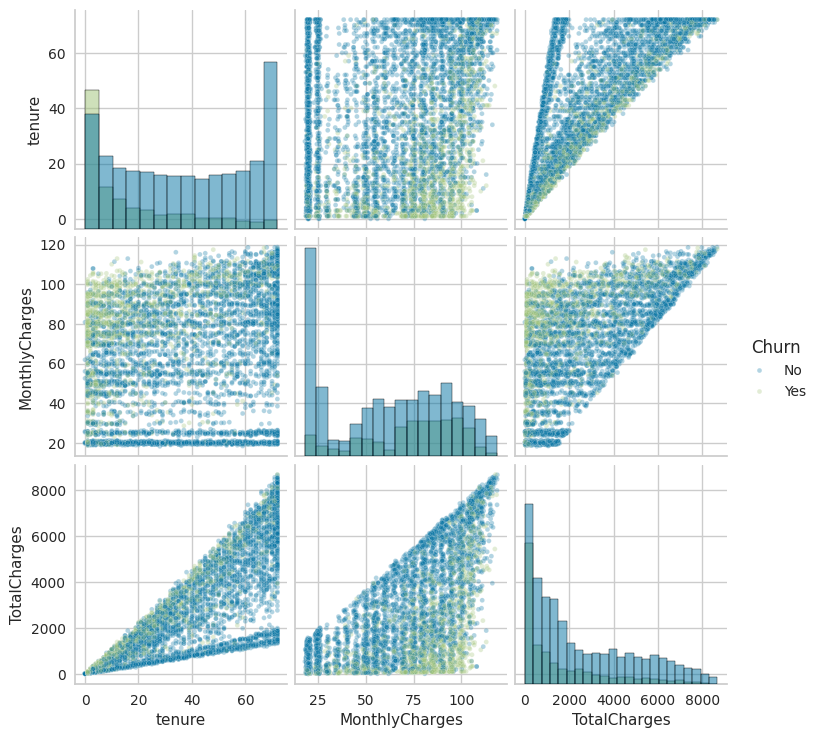

In [15]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"] # removing senior citizen (numerical category)- it has 1 or 0

sns.pairplot(
    data=df,
    vars=numeric_features,
    hue="Churn",
    diag_kind="hist",
    plot_kws={"alpha": 0.3, "s": 12}
)

plt.show()

***
Blue = stayed and orange = churned
**initial observations from numerical features**

- Tenure: orange points are concentrated at shorter tenures. Churn appears less common among long-term customers.
- MonthlyCharges: churners appear concentrated around higher monthly charges, roughly 70–110.
- TotalCharges: many churners have low total charges, which may reflect their shorter tenure.
Tenure and TotalCharges: total charges generally increase with tenure, as expected.

***

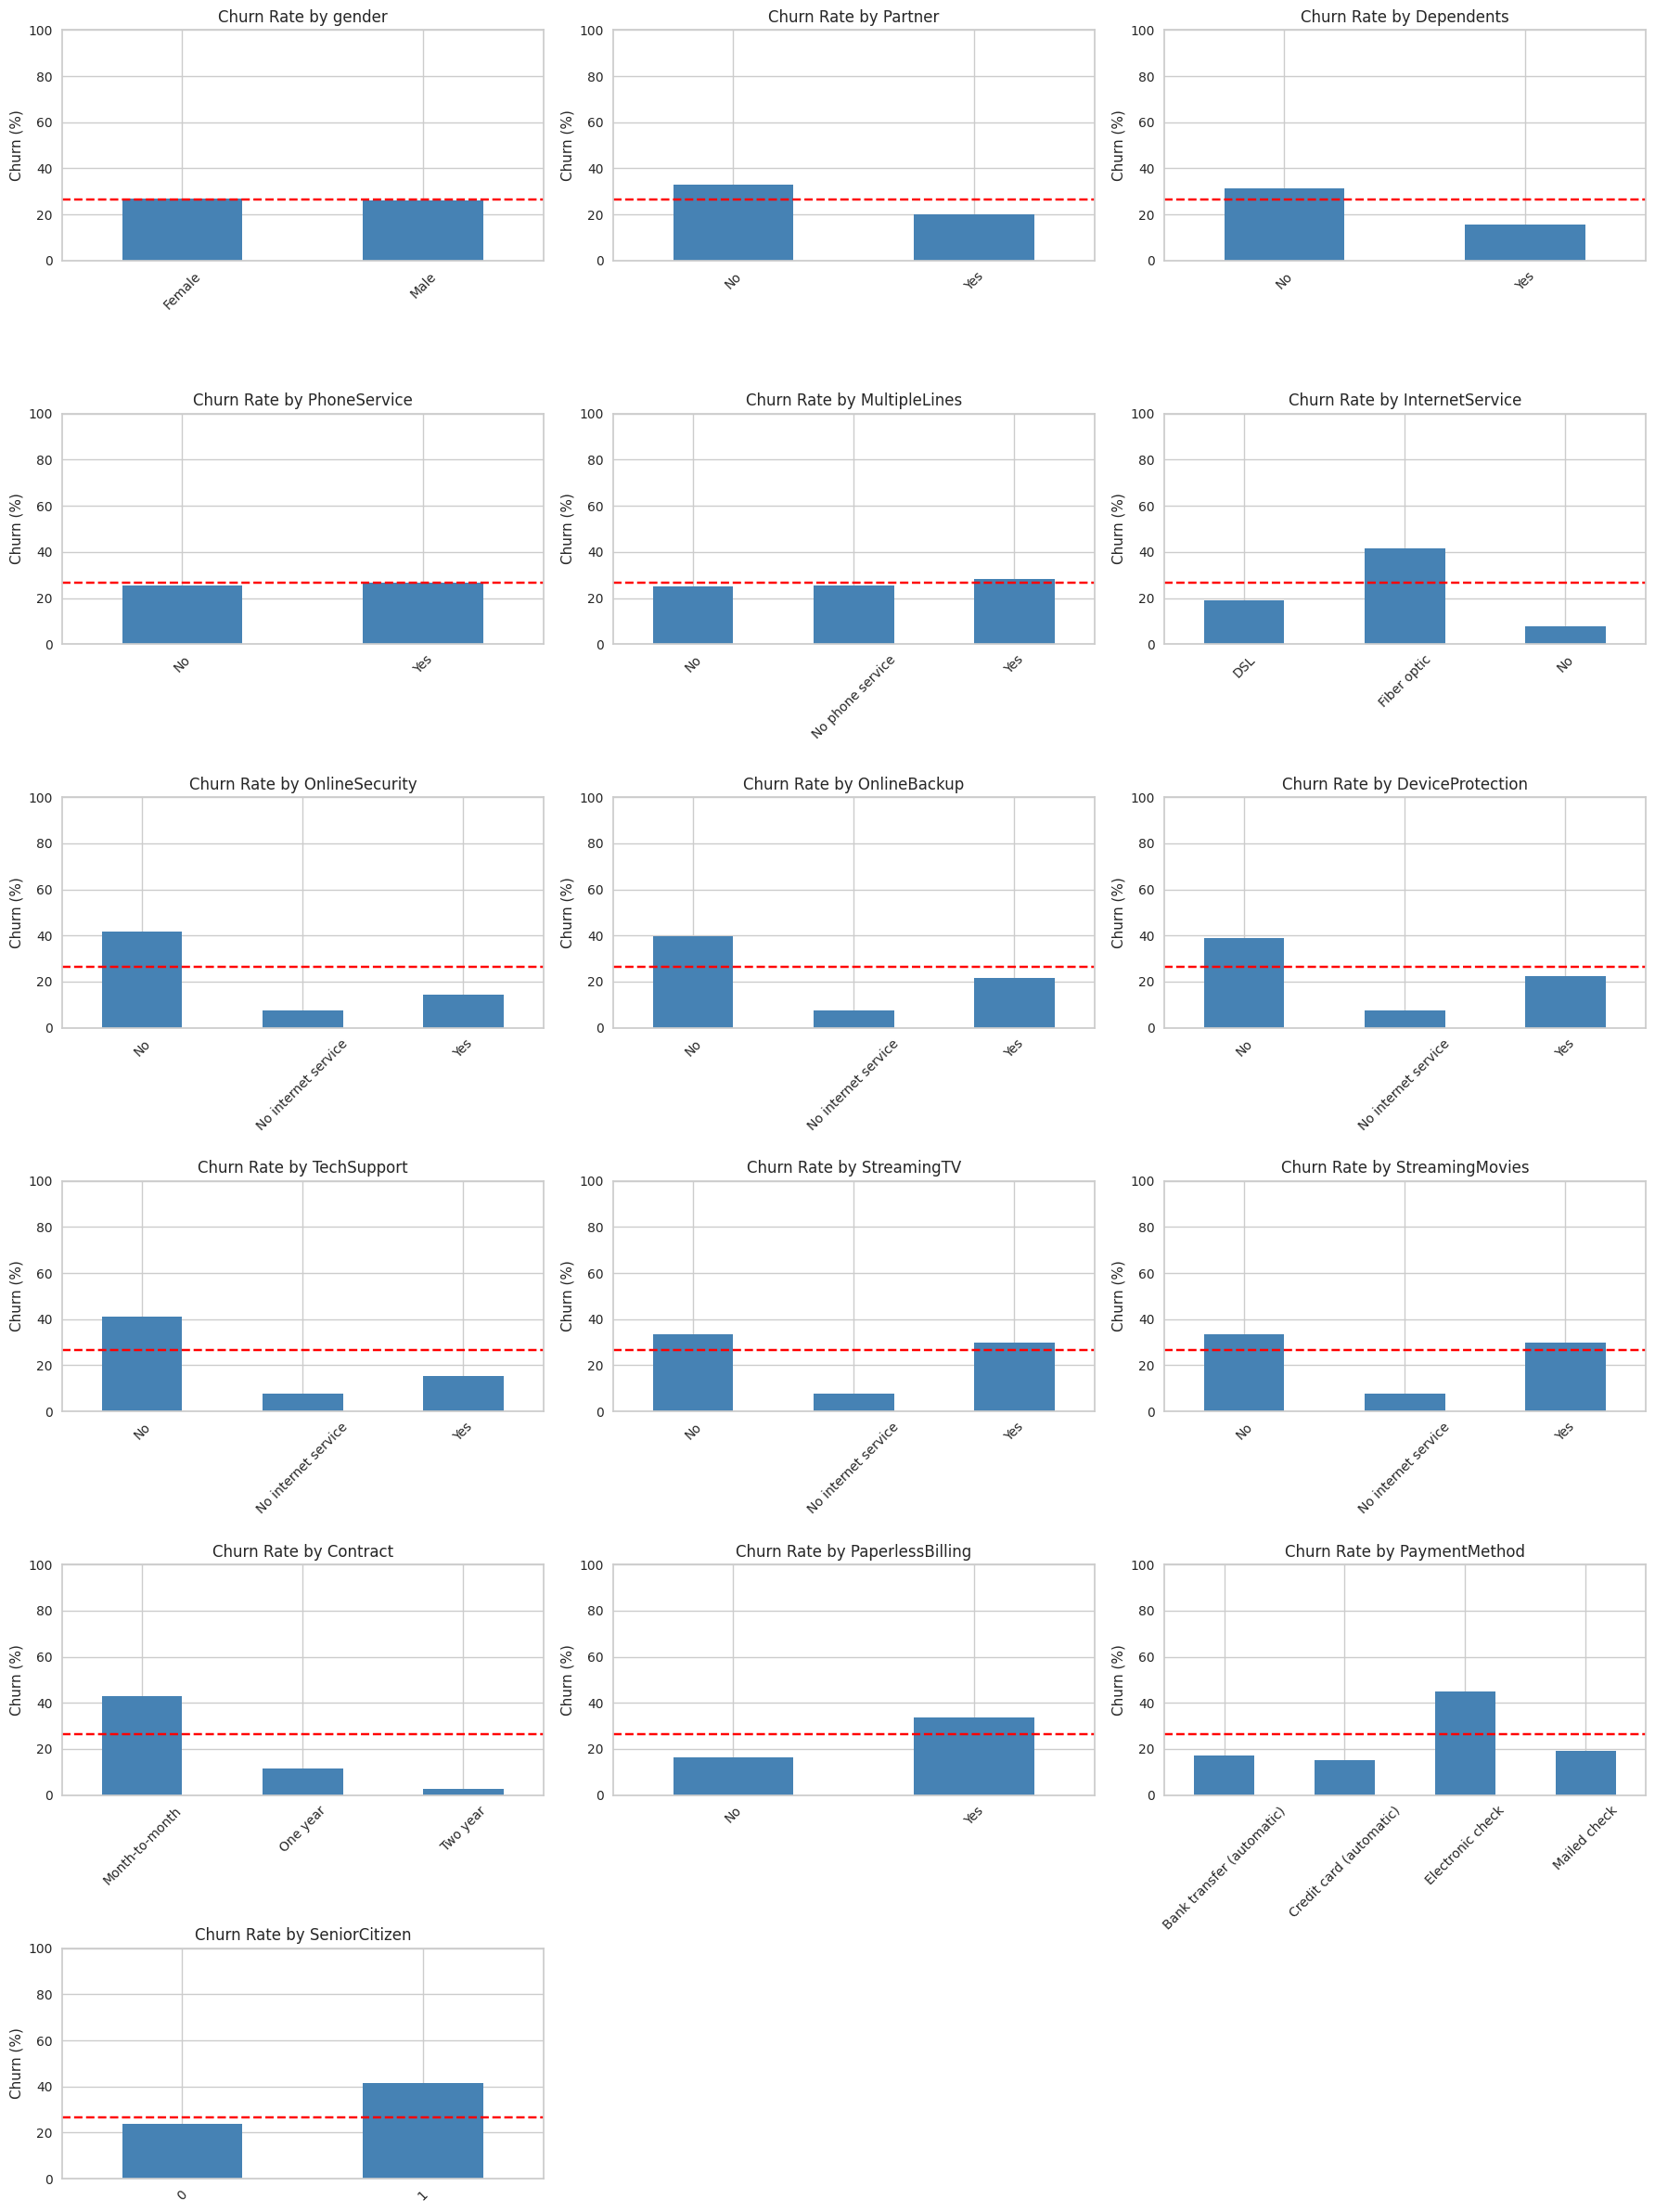

In [16]:
# lets comparre categorical features
categorical_features = [col for col in df.select_dtypes(include="object").columns
    if col not in ["customerID", "Churn"] # don't want customer id and churn
] + ["SeniorCitizen"] #adding senior citizen to category

ncols = 3
nrows = math.ceil(len(categorical_features) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda values: values.eq("Yes").mean())
        .mul(100)
    )

    churn_rate.plot.bar(ax=ax, color="steelblue")
    ax.axhline(
        df["Churn"].eq("Yes").mean() * 100,
        color="red", linestyle="--"
    )
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

***
A high churn rate means a larger percentage of customers in that group left the company.

**Observations from Categorical Features**

1. Gender: Male and female customers have similar churn rates.
2. Partner: Customers without a partner have higher churn.
3. Dependents: Customers without dependents have higher churn.
4. PhoneService: Customers with and without phone service have similar churn rates.
5. MultipleLines: Customers with multiple lines have slightly higher churn.
6. InternetService: Fiber-optic customers have the highest churn; customers without internet have the lowest.
7. OnlineSecurity: Customers without online security have higher churn than those with it.
8. OnlineBackup: Customers without online backup have higher churn than those with it.
9. DeviceProtection: Customers without device protection have higher churn than those with it.
10. TechSupport: Customers without technical support have higher churn than those with it.
11. StreamingTV: Among internet customers, those without streaming TV have slightly higher churn.
12. StreamingMovies: Among internet customers, those without streaming movies have slightly higher churn.
13. Contract: Month-to-month customers have the highest churn; two-year customers have the lowest.
14. PaperlessBilling: Customers using paperless billing have higher churn.
15. PaymentMethod: Electronic-check users have the highest churn.
16. SeniorCitizen: Senior citizens have higher churn than non-senior customers.

***

## Data Modelling

In [17]:
# Features: exclude the ID and target
X = df.drop(columns=["customerID", "Churn"])

# Target: 1 = churn, 0 = stayed
y = df["Churn"].map({"No": 0, "Yes": 1})

# 80% training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y # split churn equally
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining churn percentages:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest churn percentages:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training shape: (4788, 19)
Test shape: (1198, 19)

Training churn percentages:
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64

Test churn percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


***
*let's keep the test set aside until we’ve selected the model, hyperparameters and decision threshold.*
*evaluate models using cross-validtaion - Encoding and scaling will also be fitted inside each cross-validation training fold, using a pipeline*
- Training set + cross-validation: compare models, tune parameters and choose the threshold.
-Test set: evaluate the chosen model once to estimate performance on unseen customers.

After seeing the test results, we shouldn’t keep adjusting the model to improve that score—that would make the test set part of model selection.
***

#### preprocessing features before modelling
scale numerical features and one-hot encode categorical features.

In [18]:
# Continuous numerical features
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Categorical features, including the binary SeniorCitizen indicator
categorical_features = [col for col in X_train.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"),
         categorical_features)
    ]
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [19]:
preprocessor

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

In [20]:
display(X_train[numeric_features].describe())

,tenure,MonthlyCharges,TotalCharges
count,4788.000000,4788.000000,4788.000000
mean,32.482038,64.789265,2294.268369
std,24.488379,30.313332,2275.700333
min,0.000000,18.250000,0.000000
25%,9.000000,35.037500,400.225000
50%,29.000000,70.550000,1400.100000
75%,55.000000,90.062500,3857.337500
max,72.000000,118.750000,8672.450000


In [21]:
# Fit a separate copy for inspection
preview_preprocessor = clone(preprocessor)
X_preview = preview_preprocessor.fit_transform(X_train)

# Convert sparse output to a dense array if necessary
if hasattr(X_preview, "toarray"):
    X_preview = X_preview.toarray()

preview_df = pd.DataFrame(
    X_preview,
    columns=preview_preprocessor.get_feature_names_out(),
    index=X_train.index
)

print("Before preprocessing:", X_train.shape)
print("After preprocessing:", preview_df.shape)
display(preview_df.head())

Before preprocessing: (4788, 19)
After preprocessing: (4788, 46)


,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__gender_Female,categorical__gender_Male,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,...,categorical__StreamingMovies_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check
3625,-0.305566,1.455312,0.226232,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2608,-0.223886,1.178177,0.166639,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4856,1.123832,-1.446355,-0.449895,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3303,-0.877326,-0.192650,-0.743879,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1089,1.001313,0.175213,0.711518,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


#### find a model

In [22]:
# lets first do a baseline logistic regression mannually then try AutoML to find a best model
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])
lr_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [23]:
# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [24]:
# first baseline - logistic regression
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

scores = cross_validate(
    lr_pipeline, # fits preprocessing inside each training fold and evaluates on its validation fold.
    X_train,
    y_train,
    cv=cv, 
    scoring=metrics,
    n_jobs=-1
)

lr_results = pd.DataFrame({metric: scores[f"test_{metric}"]for metric in metrics})

display(lr_results)
display(lr_results.agg(["mean", "std"]))

,accuracy,precision,recall,f1,roc_auc
0,0.810021,0.653846,0.602362,0.627049,0.848453
1,0.795407,0.649485,0.496063,0.562500,0.819748
2,0.822547,0.694444,0.590551,0.638298,0.866880
3,0.797283,0.645320,0.517787,0.574561,0.847310
4,0.787879,0.616438,0.531496,0.570825,0.841237


,accuracy,precision,recall,f1,roc_auc
mean,0.802627,0.651907,0.547652,0.594647,0.844726
std,0.013690,0.027931,0.046497,0.035212,0.016937


***
**Baseline - Logistic Regression**
*validation results at the default prediction threshold*
Accuracy: 80.26% — higher than the 73.49% “everyone stays” baseline.
Precision: 65.19% — about 65% of customers flagged as churners actually churned.
Recall: 54.77% — it identified about 55% of actual churners, missing about 45%.
F1: 0.595 — our baseline balance between precision and recall.
ROC-AUC: 0.845 — the model separates churners from non-churners reasonably well across thresholds.
***

##### Use AutoML to find a model

In [25]:
# combine my training data into one dataset
train_data = X_train.copy()
train_data["Churn"] = y_train

exp = ClassificationExperiment() #using pyCaret

exp.setup(
    data=train_data,
    target="Churn",
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    normalize=True, #pyCaret uses z-score scaling by default (similar to StandardScaler)
    train_size=0.8, # splitting training data further into 80% train and 20 % test
    data_split_stratify=True, # equal portions in train and test split
    fold_strategy="stratifiedkfold", # similar portion of target inside each fold
    fold=5,
    fold_shuffle=True,
    session_id=42, #seed
    n_jobs=2, #use 2 available cores
    verbose=True # displays the setup summary and progress information
)

,Description,Value
0,Session id,42
1,Target,Churn
2,Target type,Binary
3,Original data shape,"(4788, 20)"
4,Transformed data shape,"(4788, 41)"
5,Transformed train set shape,"(3830, 41)"
6,Transformed test set shape,"(958, 41)"
7,Numeric features,3
8,Categorical features,16
9,Preprocess,True


In [26]:
# compare models and keep the top three by F1 
# x_test is still not used!
top_five_models = exp.compare_models(sort="F1", n_select=5)

automl_results = exp.pull()
display(automl_results)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,23:35:05
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.7016,0.8159,0.8345,0.4651,0.5972,0.3894,0.4315,0.2260
lr,Logistic Regression,0.8005,0.8416,0.5438,0.6481,0.5909,0.4604,0.4638,0.6640
lda,Linear Discriminant Analysis,0.7961,0.8357,0.5498,0.6341,0.5882,0.4537,0.4562,0.2440
ada,Ada Boost Classifier,0.7992,0.8433,0.5291,0.6504,0.5825,0.4523,0.4571,0.3140
ridge,Ridge Classifier,0.7977,0.8358,0.5113,0.6515,0.5722,0.4424,0.4484,0.1600
catboost,CatBoost Classifier,0.7948,0.8332,0.5172,0.6411,0.5715,0.4388,0.4438,1.7300
svm,SVM - Linear Kernel,0.7590,0.8071,0.6069,0.5420,0.5693,0.4035,0.4073,0.1980
gbc,Gradient Boosting Classifier,0.7937,0.8420,0.5064,0.6407,0.5652,0.4325,0.4379,0.4700
lightgbm,Light Gradient Boosting Machine,0.7828,0.8303,0.5143,0.6068,0.5563,0.4138,0.4166,0.3100
rf,Random Forest Classifier,0.7906,0.8230,0.4926,0.6357,0.5542,0.4205,0.4268,0.3700


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.7016,0.8159,0.8345,0.4651,0.5972,0.3894,0.4315,0.226
lr,Logistic Regression,0.8005,0.8416,0.5438,0.6481,0.5909,0.4604,0.4638,0.664
lda,Linear Discriminant Analysis,0.7961,0.8357,0.5498,0.6341,0.5882,0.4537,0.4562,0.244
ada,Ada Boost Classifier,0.7992,0.8433,0.5291,0.6504,0.5825,0.4523,0.4571,0.314
ridge,Ridge Classifier,0.7977,0.8358,0.5113,0.6515,0.5722,0.4424,0.4484,0.160
catboost,CatBoost Classifier,0.7948,0.8332,0.5172,0.6411,0.5715,0.4388,0.4438,1.730
svm,SVM - Linear Kernel,0.7590,0.8071,0.6069,0.5420,0.5693,0.4035,0.4073,0.198
gbc,Gradient Boosting Classifier,0.7937,0.8420,0.5064,0.6407,0.5652,0.4325,0.4379,0.470
lightgbm,Light Gradient Boosting Machine,0.7828,0.8303,0.5143,0.6068,0.5563,0.4138,0.4166,0.310
rf,Random Forest Classifier,0.7906,0.8230,0.4926,0.6357,0.5542,0.4205,0.4268,0.370


***
- Naive Bayes ranks first by F1, but logistic regression is very close.
    - F1 0.5972, recall 83.45%, precision 46.51%. It catches more churners, but over half of its churn alerts are false alarms.
- Logistic regression: F1 0.5909, recall 54.38%, precision 64.81%. Fewer false alarms, but more missed churners.
- LDA: F1 0.5882, with a similar precision–recall balance to logistic regression.
- AdaBoost and Ridge are close enough

The F1 difference is small, so we haven’t established a clear winner yet. 
Also, these models use default configurations; tuning and threshold selection may change the ranking.
***

In [27]:
# tune all 5 models
tuned_models = []
tuning_results = {}

for model in top_five_models:
    name = type(model).__name__
    print(f"\nTuning {name}")

    tuned = exp.tune_model(
        model,
        optimize="F1",
        n_iter=30,# try 30 different hyperparameter combinations during the default random search.
        choose_better=True # keeps the original model if tuning doesn’t improve its cross-validation F1.
    )

    tuned_models.append(tuned)
    tuning_results[name] = exp.pull().copy()


Tuning GaussianNB


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6802,0.8045,0.8276,0.4444,0.5783,0.3564,0.4013
1,0.6789,0.7824,0.7980,0.4414,0.5684,0.3448,0.3833
2,0.7193,0.8284,0.8325,0.4829,0.6112,0.4150,0.4528
3,0.7180,0.8413,0.8867,0.4826,0.6250,0.4290,0.4802
4,0.7115,0.8232,0.8374,0.4749,0.6061,0.4047,0.4454
Mean,0.7016,0.8160,0.8365,0.4652,0.5978,0.3900,0.4326
Std,0.0182,0.0205,0.0286,0.0185,0.0211,0.0333,0.0353


Fitting 5 folds for each of 28 candidates, totalling 140 fits

Tuning LogisticRegression


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7232,0.8367,0.8128,0.4867,0.6089,0.4149,0.4476
1,0.7324,0.8219,0.7635,0.4968,0.6019,0.4137,0.4354
2,0.7742,0.8559,0.8030,0.5507,0.6533,0.4943,0.5137
3,0.7520,0.8488,0.8128,0.5205,0.6346,0.4602,0.4864
4,0.7611,0.8430,0.7882,0.5333,0.6362,0.4680,0.4878
Mean,0.7486,0.8412,0.7961,0.5176,0.6270,0.4502,0.4742
Std,0.0186,0.0116,0.0186,0.0234,0.0189,0.0314,0.0287


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning LinearDiscriminantAnalysis


...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning AdaBoostClassifier


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8003,0.8356,0.5517,0.6437,0.5942,0.4627,0.4652
1,0.7937,0.8234,0.5369,0.6301,0.5798,0.4443,0.4468
2,0.8042,0.8641,0.5074,0.6732,0.5787,0.4544,0.4621
3,0.8042,0.8539,0.4926,0.6803,0.5714,0.4487,0.4585
4,0.8016,0.8506,0.4778,0.6783,0.5607,0.4375,0.4487
Mean,0.8008,0.8455,0.5133,0.6611,0.5769,0.4495,0.4562
Std,0.0038,0.0143,0.0274,0.0204,0.0110,0.0086,0.0073


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).

Tuning RidgeClassifier


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6893,0.8343,0.8473,0.4538,0.5911,0.3755,0.4234
1,0.6893,0.8092,0.8128,0.4521,0.5810,0.3646,0.4043
2,0.7376,0.8474,0.8374,0.5030,0.6285,0.4445,0.4791
3,0.7193,0.8494,0.8670,0.4835,0.6208,0.4252,0.4711
4,0.7311,0.8384,0.8325,0.4956,0.6213,0.4329,0.4680
Mean,0.7133,0.8357,0.8394,0.4776,0.6085,0.4086,0.4492
Std,0.0205,0.0144,0.0178,0.0211,0.0188,0.0322,0.0297


Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [28]:
# display the mean cv score of the 5 models
best_tuned = exp.compare_models(
    include=tuned_models,
    sort="F1",
    n_select=1
)

tuned_comparison = exp.pull()
display(tuned_comparison)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
2,Linear Discriminant Analysis,0.7804,0.8357,0.7015,0.5709,0.6287,0.4754,0.4811,0.1700
1,Logistic Regression,0.7486,0.8412,0.7961,0.5176,0.6270,0.4502,0.4742,0.1760
4,Ridge Classifier,0.7133,0.8357,0.8394,0.4776,0.6085,0.4086,0.4492,0.2580
0,Naive Bayes,0.7016,0.8160,0.8365,0.4652,0.5978,0.3900,0.4326,0.1920
3,Ada Boost Classifier,0.7992,0.8433,0.5291,0.6504,0.5825,0.4523,0.4571,0.3460


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
2,Linear Discriminant Analysis,0.7804,0.8357,0.7015,0.5709,0.6287,0.4754,0.4811,0.170
1,Logistic Regression,0.7486,0.8412,0.7961,0.5176,0.6270,0.4502,0.4742,0.176
4,Ridge Classifier,0.7133,0.8357,0.8394,0.4776,0.6085,0.4086,0.4492,0.258
0,Naive Bayes,0.7016,0.8160,0.8365,0.4652,0.5978,0.3900,0.4326,0.192
3,Ada Boost Classifier,0.7992,0.8433,0.5291,0.6504,0.5825,0.4523,0.4571,0.346


***
- LDA: F1 0.6287, precision 57.09%, recall 70.15%.
- Logistic regression: F1 0.6270, precision 51.76%, recall 79.61%.

LDA produces fewer false alarms; logistic regression catches more churners. 
The F1 difference of 0.0017 is too small to call LDA clearly superior.
***

In [29]:
# lets see the tunned hyperparameters
print(type(best_tuned).__name__)
display(best_tuned.get_params())

LinearDiscriminantAnalysis


{'covariance_estimator': None,
 'n_components': None,
 'priors': None,
 'shrinkage': 0.6,
 'solver': 'lsqr',
 'store_covariance': False,
 'tol': 0.0001}

In [30]:
tuned_lr = next(model for model in tuned_models if isinstance(model, LogisticRegression))

display(tuned_lr.get_params())

{'C': 3.211,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 1000,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

***
PyCarret choose: F1 score
Tuned LDA: 0.6287
Tuned logistic regression: 0.6270
***

In [33]:
# lets try FLAML also to check
# Original features before PyCaret's encoding and scaling
X_flaml = exp.get_config("X_train").copy()
y_flaml = exp.get_config("y_train").copy()

# Mark categorical features for FLAML
for col in categorical_features:
    X_flaml[col] = X_flaml[col].astype("category")

print("FLAML feature shape:", X_flaml.shape)
print("FLAML target shape:", y_flaml.shape)
display(X_flaml.dtypes)

FLAML feature shape: (3830, 19)
FLAML target shape: (3830,)


gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                  int8
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float32
TotalCharges         float32
dtype: object

In [ ]:
automl = AutoML()

automl.fit(
    X_train=X_flaml,
    y_train=y_flaml,
    task="classification",
    metric="f1",
    eval_method="cv",
    split_type=exp.get_config("fold_generator"),
    n_splits=5,
    time_budget=600,
    n_jobs=2,
    seed=42,
    sample=False,
    verbose=3
)

print("Best model:", automl.best_estimator)
print("Best parameters:", automl.best_config)
print("Best CV F1:", round(1 - automl.best_loss, 4))

[flaml.automl.logger: 10-01 14:06:49] {2470} INFO - task = classification
[flaml.automl.logger: 10-01 14:06:49] {2481} INFO - Evaluation method: cv
[flaml.automl.logger: 10-01 14:06:49] {2584} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 10-01 14:06:49] {2701} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 10-01 14:06:49] {3006} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 10-01 14:06:50] {3141} INFO - Estimated sufficient time budget=1134s. Estimated necessary time budget=28s.
[flaml.automl.logger: 10-01 14:06:50] {3192} INFO -  at 0.2s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 10-01 14:06:50] {3006} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 10-01 14:06:50] {3192} INFO -  at 0.3s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flam

***
FLAML selected XGBoost, but its best CV F1 is lower than our tuned PyCaret models:
Tuned LDA: 0.6287
Tuned logistic regression: 0.6270
(PyCaret compare_models(): compared default model settings. We then tuned LDA and logistic regression separately)
FLAML XGBoost: 0.5984
(flaml - searched model types and hyperparameters together. The XGBoost parameters it returned are already its best-found configuration. )
***

##### Lets try some model based feature selection

In [31]:
#Let’s first define the feature-selection pipeline
# L1 regularization can set some coefficients to zero
selector = SelectFromModel(
    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),
    threshold=1e-5
)

lr_selection_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)), # encode and scale
    ("selection", selector), # select feature
    ("model", clone(tuned_lr)) # fit the classifier
])

lr_selection_pipeline

Pipeline(memory=None,
         steps=[('preprocessor',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('numeric',
                                                  StandardScaler(copy=True,
                                                                 with_mean=True,
                                                                 with_std=True),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(categories='auto',
                                                                drop=None,
                                                                dtype=<class 'numpy.float64'>,
                                                                fea...
                                 importance_getter='auto', max_features=None,
                                 norm_order=1, prefit=False, threshold=1e-05)),
                ('model',
                 LogisticRegression(C=3.211, class_weight='balanced',
                                    dual=False, fit_intercept=True,
                                    intercept_scaling=1, l1_ratio=None,
                                    max_iter=1000, multi_class='auto',
                                    n_jobs=None, penalty='l2', random_state=42,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

In [34]:
# compare the same tuned logistic regression with and without feature selection
lr_all_features = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", clone(tuned_lr))
])

pipelines = {
    "All features": lr_all_features,
    "L1 feature selection": lr_selection_pipeline
}

metrics = ["precision", "recall", "f1", "roc_auc"]
comparison = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_flaml,
        y_flaml,
        cv=exp.get_config("fold_generator"),
        scoring=metrics,
        n_jobs=2
    )

    comparison.append({
        "Method": name,
        **{
            metric: scores[f"test_{metric}"].mean()
            for metric in metrics
        },
        "F1 std": scores["test_f1"].std()
    })

selection_comparison = pd.DataFrame(comparison).set_index("Method")
display(selection_comparison.round(4))

,precision,recall,f1,roc_auc,F1 std
Method,,,,,
All features,0.5169,0.7961,0.6265,0.8413,0.0182
L1 feature selection,0.5169,0.7961,0.6265,0.8413,0.0184


In [35]:
# Fit for inspection; the CV scores above remain unchanged
lr_selection_pipeline.fit(X_flaml, y_flaml)

feature_names = (
    lr_selection_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_mask = (
    lr_selection_pipeline.named_steps["selection"]
    .get_support()
)

print("Total encoded features:", len(feature_names))
print("Selected features:", selected_mask.sum())
print("Removed features:", (~selected_mask).sum())

print("\nRemoved features:")
print(feature_names[~selected_mask].tolist())

Total encoded features: 46
Selected features: 27
Removed features: 19

Removed features:
['categorical__gender_Female', 'categorical__SeniorCitizen_1', 'categorical__Partner_No', 'categorical__Dependents_Yes', 'categorical__PhoneService_No', 'categorical__MultipleLines_No phone service', 'categorical__MultipleLines_Yes', 'categorical__InternetService_No', 'categorical__OnlineSecurity_No internet service', 'categorical__OnlineBackup_No internet service', 'categorical__DeviceProtection_No internet service', 'categorical__TechSupport_No internet service', 'categorical__StreamingTV_No', 'categorical__StreamingTV_No internet service', 'categorical__StreamingTV_Yes', 'categorical__StreamingMovies_No internet service', 'categorical__Contract_One year', 'categorical__PaperlessBilling_Yes', 'categorical__PaymentMethod_Mailed check']


Feature Selection Result on Logistic regression

- L1-based selection retained 27 of 46 encoded features.
- Cross-validation F1 stayed approximately unchanged at 0.6265.
- The reduced feature set achieved similar predictive performance.
- Removed columns may contain redundant information rather than irrelevant information.
- The selected features can vary between cross-validation folds.

In [36]:
# let's see feature selection on LDA
# L1 logistic regression selects the features, and LDA makes the predictions
lda_all_features = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", clone(best_tuned))
])

lda_selection_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("selection", clone(selector)),
    ("model", clone(best_tuned))
])

lda_comparison = []

for name, pipeline in {
    "LDA: all features": lda_all_features,
    "LDA: L1 selection": lda_selection_pipeline
}.items():

    scores = cross_validate(
        pipeline,
        X_flaml,
        y_flaml,
        cv=exp.get_config("fold_generator"),
        scoring=metrics,
        n_jobs=2
    )

    lda_comparison.append({
        "Method": name,
        **{
            metric: scores[f"test_{metric}"].mean()
            for metric in metrics
        },
        "F1 std": scores["test_f1"].std()
    })

display(
    pd.DataFrame(lda_comparison)
    .set_index("Method")
    .round(4)
)

,precision,recall,f1,roc_auc,F1 std
Method,,,,,
LDA: all features,0.5838,0.6897,0.6314,0.8375,0.0080
LDA: L1 selection,0.5929,0.6808,0.6329,0.8381,0.0085


In [38]:
# PyCaret's internal training and validation subsets
X_flaml = exp.get_config("X_train").copy()
y_flaml = exp.get_config("y_train").copy()

X_validation = exp.get_config("X_test").copy()
y_validation = exp.get_config("y_test").copy()

validation_models = {
    "LDA + selection": clone(lda_selection_pipeline),
    "LR + selection": clone(lr_selection_pipeline)
}

validation_probabilities = {}

for name, model in validation_models.items():
    model.fit(X_flaml, y_flaml)

    positive_class_index = list(model.classes_).index(1)

    validation_probabilities[name] = model.predict_proba(
        X_validation
    )[:, positive_class_index]

print("Validation customers:", len(y_validation))

Validation customers: 958


***
Feature selection on LDA:
    - only a very small improvement
    F1: 0.6314 → 0.6329
    Precision: 58.38% → 59.29%
    Recall: 68.97% → 68.08%
    ROC-AUC: 0.8375 → 0.8381

It produces slightly fewer false alarms but misses slightly more churners.
***

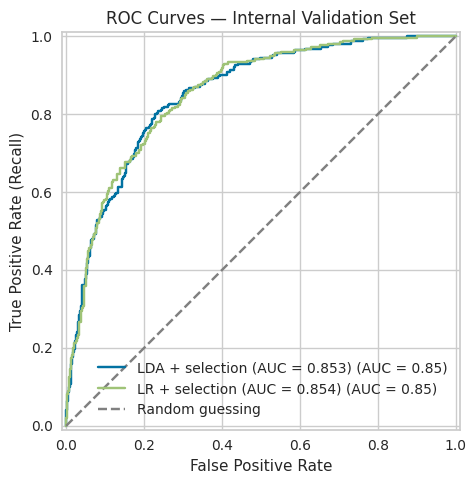

In [39]:
# compare LDA and logistic regression across probability thresholds
#lets plot ROC curve for both first
fig, ax = plt.subplots(figsize=(7, 5))
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

for name, probabilities in validation_probabilities.items():
    auc = roc_auc_score(y_validation, probabilities)

    RocCurveDisplay.from_predictions(
        y_validation,
        probabilities,
        name=f"{name} (AUC = {auc:.3f})",
        ax=ax
    )

ax.plot([0, 1], [0, 1], "--", color="gray", label="Random guessing")
ax.set_title("ROC Curves — Internal Validation Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [40]:
#fit the two pipelines with feature selection on the 3,830 customers and get churn probabilities for the 958-customer internal holdout
# PyCaret's internal holdout—not our final test set
X_validation = exp.get_config("X_test").copy()
y_validation = exp.get_config("y_test").copy()

validation_models = {
    "LDA + selection": clone(lda_selection_pipeline),
    "LR + selection": clone(lr_selection_pipeline)
}

validation_probabilities = {}

for name, pipeline in validation_models.items():
    pipeline.fit(X_flaml, y_flaml)

    # Find the probability column corresponding to churn = 1
    churn_index = list(pipeline.classes_).index(1)

    validation_probabilities[name] = pipeline.predict_proba(X_validation)[:, churn_index]

print("Validation customers:", len(y_validation))

Validation customers: 958


In [41]:
# compare thresholds from 0.10 to 0.90
threshold_results = []

for name, probabilities in validation_probabilities.items():
    for step in range(10, 91, 5):
        threshold = step / 100
        predictions = (probabilities >= threshold).astype(int)

        threshold_results.append({
            "Model": name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_validation, predictions, zero_division=0
            ),
            "Recall": recall_score(
                y_validation, predictions, zero_division=0
            ),
            "F1": f1_score(
                y_validation, predictions, zero_division=0
            ),
            "Flagged customers": predictions.sum()
        })

threshold_df = pd.DataFrame(threshold_results)

# Show the five highest-F1 thresholds for each model
for name in validation_models:
    print(f"\n{name}")
    display(
        threshold_df[threshold_df["Model"] == name]
        .sort_values("F1", ascending=False)
        .head(5)
        .round(4)
    )


LDA + selection


,Model,Threshold,Precision,Recall,F1,Flagged customers
4,LDA + selection,0.30,0.5568,0.7913,0.6537,361
3,LDA + selection,0.25,0.5417,0.8189,0.6520,384
6,LDA + selection,0.40,0.5775,0.7480,0.6518,329
5,LDA + selection,0.35,0.5652,0.7677,0.6511,345
7,LDA + selection,0.45,0.5865,0.7205,0.6466,312



LR + selection


,Model,Threshold,Precision,Recall,F1,Flagged customers
28,LR + selection,0.65,0.6121,0.6772,0.6430,281
26,LR + selection,0.55,0.5472,0.7756,0.6417,360
29,LR + selection,0.70,0.6569,0.6181,0.6369,239
27,LR + selection,0.60,0.5679,0.7244,0.6367,324
25,LR + selection,0.50,0.5176,0.8110,0.6319,398


***
LDA + selection at threshold 0.30 has the highest validation F1 among the combinations

F1: 0.6537
Precision: 55.68%
Recall: 79.13%
361 customers flagged: 201 actual churners and 160 false alarms.
53 churners missed.

Logistic regression’s best threshold was 0.65, with F1 0.6430. It produced fewer alerts, but missed more churners.
***

#### final model selected: LDA + selection with threshold 0.30

In [42]:
# refits preprocessing, selection and LDA using all our training data
chosen_model_name = "LDA + selection"
chosen_threshold = 0.30

# Refit the chosen pipeline on all 4,788 training customers
final_pipeline = clone(validation_models[chosen_model_name])
final_pipeline.fit(X_train, y_train)

print("Chosen model:", chosen_model_name)
print("Chosen threshold:", chosen_threshold)

Chosen model: LDA + selection
Chosen threshold: 0.3


In [43]:
# evaluate the final test set using the fixed 0.30 threshold.
churn_index = list(final_pipeline.classes_).index(1)

test_probabilities = final_pipeline.predict_proba(X_test)[:, churn_index]
test_predictions = (
    test_probabilities >= chosen_threshold
).astype(int)

test_results = pd.Series({
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(y_test, test_predictions, zero_division=0),
    "Recall": recall_score(y_test, test_predictions, zero_division=0),
    "F1": f1_score(y_test, test_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_probabilities)
})

display(test_results.round(4))

Accuracy     0.7279
Precision    0.4914
Recall       0.7170
F1           0.5831
ROC-AUC      0.8160
dtype: float64

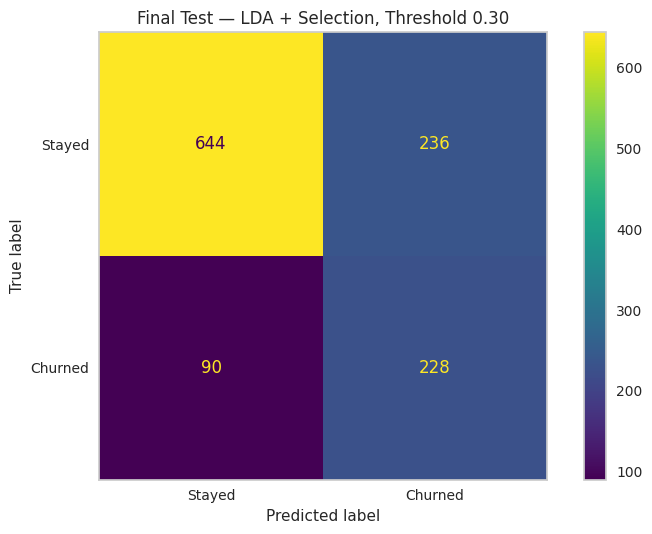

In [44]:
# plot confusion matrix
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

disp =ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions,
        labels=[0, 1],
        display_labels=["Stayed", "Churned"],
        cmap="viridis"
    )
disp.ax_.grid(False)
plt.title("Final Test — LDA + Selection, Threshold 0.30")
plt.tight_layout()
plt.show()

***
- 644 customers correctly predicted to stay.
- 236 customers incorrectly flagged as churners (false alarms).
- 90 actual churners missed.
- 228 churners correctly identified.

Precision: 49.14% — about half of the churn alerts were correct.
Recall: 71.70% — identified about 72% of actual churners.
F1: 0.5831
Accuracy: 72.79%

Test F1 is lower than validation F1 (0.6537), showing weaker performance on unseen customers. Accuracy is also slightly below the “everyone stays” baseline, but that baseline detects zero churners.
***

,Precision,Recall,F1,Accuracy
Train (after refit),0.5339,0.7699,0.6305,0.7609
Validation (before refit),0.5568,0.7913,0.6537,0.7777
Final test,0.4914,0.7170,0.5831,0.7279


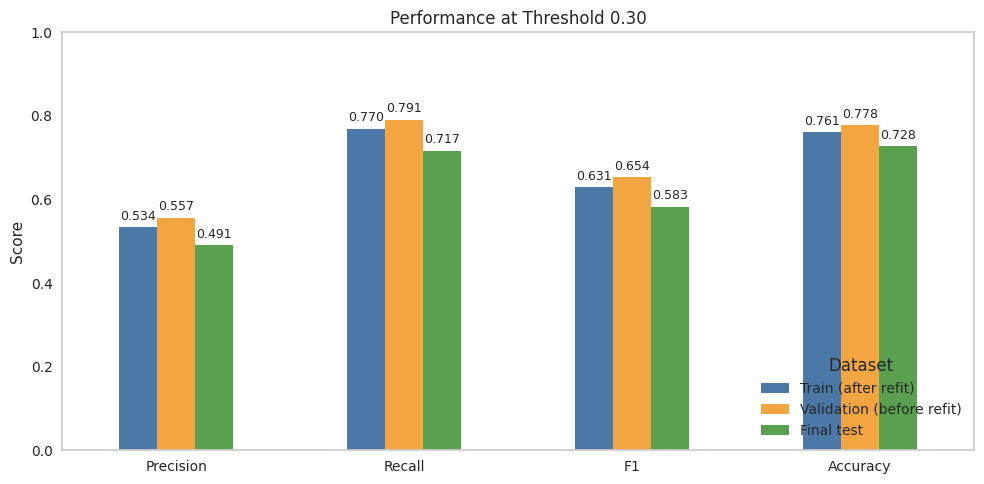

In [45]:
# plot the accuracy, precesion, recall and f1
# Training predictions from the final model
train_probabilities = final_pipeline.predict_proba(X_train)[:, churn_index]
train_predictions = (
    train_probabilities >= chosen_threshold
).astype(int)

# Saved validation probabilities from before the final refit
validation_predictions = (
    validation_probabilities[chosen_model_name] >= chosen_threshold
).astype(int)

datasets = {
    "Train (after refit)": (y_train, train_predictions),
    "Validation (before refit)": (y_validation, validation_predictions),
    "Final test": (y_test, test_predictions)
}

performance = pd.DataFrame({
    name: {
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "F1": f1_score(actual, predicted, zero_division=0),
        "Accuracy": accuracy_score(actual, predicted)
    }
    for name, (actual, predicted) in datasets.items()
}).T

display(performance.round(4))

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

ax = performance.T.plot.bar(
    figsize=(10, 5),
    color=["#4C78A8", "#F2A541", "#59A14F"],
    rot=0
)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Performance at Threshold 0.30")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.grid(False)
ax.legend(title="Dataset", loc="lower right")

plt.tight_layout()
plt.show()

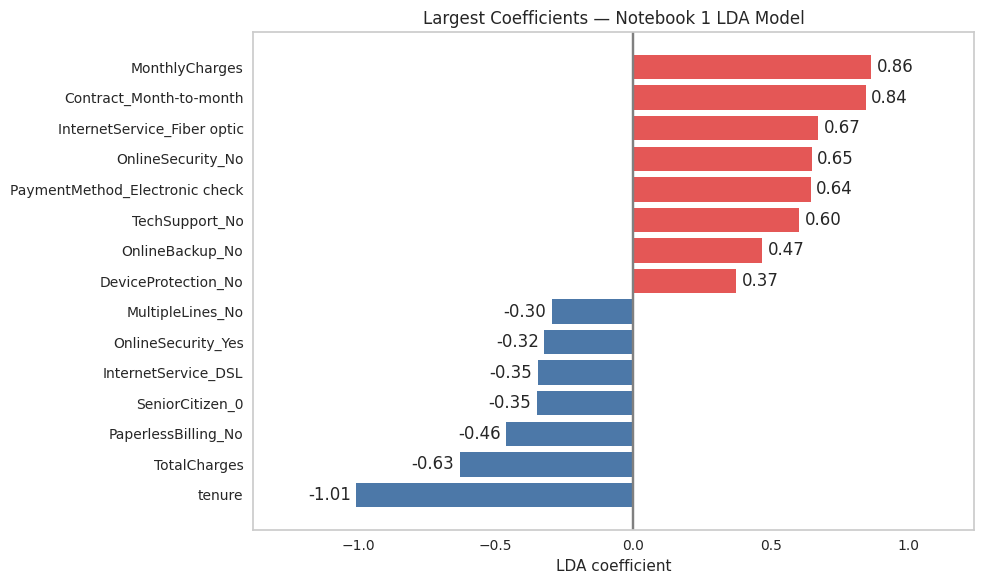

In [46]:
# LDA + feature selection model, show the coefficients of the selected encoded features.
feature_names = (
    final_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_mask = (
    final_pipeline.named_steps["selection"].get_support()
)

selected_names = feature_names[selected_mask]

# The last pipeline step is the fitted LDA model
lda_model = final_pipeline.steps[-1][1]

lda_coefficients = pd.Series(
    lda_model.coef_[0],
    index=selected_names,
    name="Coefficient"
)

top_features = lda_coefficients.loc[
    lda_coefficients.abs().nlargest(15).index
].sort_values()

labels = (
    top_features.index
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    labels,
    top_features.values,
    color=[
        "#E45756" if value > 0 else "#4C78A8"
        for value in top_features.values
    ]
)

ax.bar_label(bars, fmt="%.2f", padding=4)
ax.axvline(0, color="gray")
ax.set_xlabel("LDA coefficient")
ax.set_title("Largest Coefficients — Notebook 1 LDA Model")
ax.margins(x=0.2)
ax.grid(False)

plt.tight_layout()
plt.show()